In [27]:
import os
import cv2
import numpy as np
import pywt
import pickle
from tqdm import tqdm
from scipy.signal import wiener as scipy_wiener

In [28]:
DATASET_A = "/kaggle/input/tracer/dataset-trace/dataset-trace"
DATASET_B = "/kaggle/input/tracer/dataset-trace-2/dataset-trace-2"

# Output combined official residuals (Kaggle working directory)
OUTPUT_PKL = "/kaggle/working/combined_official_residuals.pkl"

In [29]:
IMG_SIZE = (256, 256)
DENOISE_METHOD = "wavelet"

In [30]:
def normalize_scanner_name(name):
    name = name.replace("dataset-trace-2_", "")
    name = name.replace("dataset-trace_", "")
    return name

In [31]:
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img

def resize_to(img, size=IMG_SIZE):
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

def normalize_img(img):
    return img.astype(np.float32) / 255.0

In [32]:
def denoise_wavelet_img(img):
    coeffs = pywt.dwt2(img, 'haar')
    cA, (cH, cV, cD) = coeffs
    cH[:] = 0; cV[:] = 0; cD[:] = 0
    return pywt.idwt2((cA, (cH, cV, cD)), 'haar')

In [33]:
def preprocess_image(fpath, method=DENOISE_METHOD):
    img = cv2.imread(fpath, cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"⚠️ Skipping unreadable image: {fpath}")
        return None

    img = to_gray(img)
    img = resize_to(img)
    img = normalize_img(img)

    if method == "wiener":
        den = scipy_wiener(img, mysize=(5, 5))
    else:
        den = denoise_wavelet_img(img)

    return (img - den).astype(np.float32)

In [34]:
def process_dataset(base_dir):
    residuals_dict = {}
    scanners = sorted(os.listdir(base_dir))

    for scanner in tqdm(scanners, desc=f"Processing {os.path.basename(base_dir)}"):
        scanner_dir = os.path.join(base_dir, scanner)
        if not os.path.isdir(scanner_dir):
            continue

        all_residuals = []

        dpi_dirs = [
            os.path.join(scanner_dir, d)
            for d in os.listdir(scanner_dir)
            if os.path.isdir(os.path.join(scanner_dir, d))
        ]

        if dpi_dirs:
            for d in dpi_dirs:
                imgs = [
                    os.path.join(d, f)
                    for f in os.listdir(d)
                    if f.lower().endswith((".tif", ".tiff", ".png", ".jpg"))
                ]
                for img_path in imgs:
                    res = preprocess_image(img_path)
                    if res is not None:
                        all_residuals.append(res)
        else:
            imgs = [
                os.path.join(scanner_dir, f)
                for f in os.listdir(scanner_dir)
                if f.lower().endswith((".tif", ".tiff", ".png", ".jpg"))
            ]
            for img_path in imgs:
                res = preprocess_image(img_path)
                if res is not None:
                    all_residuals.append(res)

        if all_residuals:
            residuals_dict[f"{os.path.basename(base_dir)}_{scanner}"] = all_residuals

    return residuals_dict

In [35]:
print("🔄 Processing Dataset A...")
res_A = process_dataset(DATASET_A)

print("\n🔄 Processing Dataset B...")
res_B = process_dataset(DATASET_B)

🔄 Processing Dataset A...


Processing dataset-trace: 100%|██████████| 11/11 [07:46<00:00, 42.39s/it]



🔄 Processing Dataset B...


Processing dataset-trace-2: 100%|██████████| 11/11 [07:25<00:00, 40.53s/it]


In [36]:
# Merge dictionaries: if scanner exists in both → concatenate lists
combined_residuals = {}

for scanner in set(res_A.keys()).union(res_B.keys()):
    list_A = res_A.get(scanner, [])
    list_B = res_B.get(scanner, [])

    merged_name = normalize_scanner_name(scanner)

    combined_residuals.setdefault(merged_name, [])
    combined_residuals[merged_name].extend(list_A + list_B)

In [37]:
print("\n📦 MERGED SCANNERS:", len(combined_residuals))
for k, v in combined_residuals.items():
    print(f"  {k}: {len(v)} residuals")


📦 MERGED SCANNERS: 11
  Canon220: 410 residuals
  Canon120-2: 410 residuals
  HP: 411 residuals
  EpsonV550: 410 residuals
  Canon120-1: 410 residuals
  EpsonV370-2: 411 residuals
  EpsonV39-1: 410 residuals
  Canon9000-1: 411 residuals
  Canon9000-2: 401 residuals
  EpsonV39-2: 410 residuals
  EpsonV370-1: 410 residuals


In [38]:
import pickle, os

OUTPUT_DIR = "/kaggle/working"
COMBINED_PKL = os.path.join(OUTPUT_DIR, "combined_residuals.pkl")

with open(COMBINED_PKL, "wb") as f:
    pickle.dump(combined_residuals, f)

print(f"\n✅ Saved combined residuals → {COMBINED_PKL}")


✅ Saved combined residuals → /kaggle/working/combined_residuals.pkl


**Compute Fingerprints**

In [39]:
print("\n🔄 Computing fingerprints...")

scanner_fps = {}
for scanner, res_list in tqdm(combined_residuals.items()):
    if len(res_list) == 0:
        continue
    stack = np.stack(res_list, axis=0)
    scanner_fps[scanner] = np.mean(stack, axis=0).astype(np.float32)

FP_PATH = os.path.join(OUTPUT_DIR, "scanner_fingerprints.pkl")
FP_KEYS_PATH = os.path.join(OUTPUT_DIR, "fp_keys.npy")

with open(FP_PATH, "wb") as f:
    pickle.dump(scanner_fps, f)
np.save(FP_KEYS_PATH, np.array(sorted(scanner_fps.keys())))

print(f"📁 Fingerprints saved to: {FP_PATH}")


🔄 Computing fingerprints...


100%|██████████| 11/11 [00:00<00:00, 16.78it/s]

📁 Fingerprints saved to: /kaggle/working/scanner_fingerprints.pkl


**Feature Extraction**

In [41]:
from skimage.feature import local_binary_pattern
from scipy.fft import fft2, fftshift

print("\n🔄 Extracting handcrafted features...")

def corr2d(a, b):
    a = a.astype(np.float32).ravel()
    b = b.astype(np.float32).ravel()
    a -= a.mean(); b -= b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (a @ b) / denom if denom != 0 else 0.0

def fft_radial_energy(img, K=6):
    f = np.fft.fftshift(fft2(img))
    mag = np.abs(f)
    h, w = mag.shape
    cy, cx = h//2, w//2
    yy, xx = np.ogrid[:h, :w]
    r = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    bins = np.linspace(0, r.max(), K+1)
    return [mag[(r>=bins[i])&(r<bins[i+1])].mean() for i in range(K)]

def lbp_hist_safe(img, P=8, R=1.0):
    rng = np.ptp(img)
    if rng < 1e-12:
        return [0.0]*(P+2)
    g = (img - img.min()) / (rng + 1e-8)
    g8 = (g*255).astype(np.uint8)
    codes = local_binary_pattern(g8, P=P, R=R, method="uniform")
    hist, _ = np.histogram(codes, bins=np.arange(P+3), density=True)
    return hist.astype(np.float32).tolist()

# load fingerprints
with open(FP_PATH, "rb") as f:
    scanner_fps = pickle.load(f)
fp_keys = np.load(FP_KEYS_PATH, allow_pickle=True).tolist()

features, labels = [], []

for scanner, res_list in combined_residuals.items():
    merged_name = normalize_scanner_name(scanner)
    for res in res_list:
        v_corr = [corr2d(res, scanner_fps[k]) for k in fp_keys]
        v_fft = fft_radial_energy(res)
        v_lbp = lbp_hist_safe(res)
        features.append(v_corr + v_fft + v_lbp)
        labels.append(merged_name)

FEAT_PATH = os.path.join(OUTPUT_DIR, "features_labels.pkl")
with open(FEAT_PATH, "wb") as f:
    pickle.dump({"features": features, "labels": labels}, f)

print(f"📁 Features saved to: {FEAT_PATH}")


🔄 Extracting handcrafted features...
📁 Features saved to: /kaggle/working/features_labels.pkl


In [42]:
# ==========================================
# STEP 8: PREPARE CNN DATASET
# ==========================================

import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Convert handcrafted features to numpy
X_feat = np.array(features, dtype=np.float32)

# Convert residual images to (256,256,1)
X_img = []
y_img = []

for scanner, res_list in combined_residuals.items():
    merged_name = normalize_scanner_name(scanner)
    for res in res_list:
        X_img.append(res[..., None])
        y_img.append(merged_name)

X_img = np.array(X_img, dtype=np.float32)
y_img = np.array(y_img)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_img)

# Scale handcrafted features
scaler = StandardScaler()
X_feat_scaled = scaler.fit_transform(X_feat)

# Save all datasets
np.save(os.path.join(OUTPUT_DIR, "X_img.npy"), X_img)
np.save(os.path.join(OUTPUT_DIR, "X_feat.npy"), X_feat_scaled)
np.save(os.path.join(OUTPUT_DIR, "y.npy"), y_encoded)

with open(os.path.join(OUTPUT_DIR, "hybrid_label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

with open(os.path.join(OUTPUT_DIR, "hybrid_feat_scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

print("🔥 Dataset prepared for CNN!")

🔥 Dataset prepared for CNN!


In [43]:
# --------------------------
# 1. Setup & GPU check
# --------------------------
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf

# Print devices and set policy for GPU performance
print("TensorFlow version:", tf.__version__)
print("Physical devices:", tf.config.list_physical_devices())

# OPTIONAL: enable mixed precision for faster training on T4 / modern GPUs
# This speeds up training and reduces memory use. Works fine for most models.
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", mixed_precision.global_policy())

# Paths (Kaggle working)
WORK = "/kaggle/working"
X_IMG_PATH = os.path.join(WORK, "X_img.npy")
X_FEAT_PATH = os.path.join(WORK, "X_feat.npy")
Y_PATH = os.path.join(WORK, "y.npy")
ENCODER_PATH = os.path.join(WORK, "hybrid_label_encoder.pkl")
SCALER_PATH = os.path.join(WORK, "hybrid_feat_scaler.pkl")
FP_PATH = os.path.join(WORK, "scanner_fingerprints.pkl")     # if you saved here earlier
FP_KEYS_PATH = os.path.join(WORK, "fp_keys.npy")
MODEL_OUT_PATH = os.path.join(WORK, "scanner_hybrid_final.keras")
HISTORY_PATH = os.path.join(WORK, "hybrid_training_history.pkl")

print("Data paths:")
print(X_IMG_PATH, X_FEAT_PATH, Y_PATH)

2025-12-01 14:34:45.125280: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764599685.330111      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764599685.388584      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Data paths:
/kaggle/working/X_img.npy /kaggle/working/X_feat.npy /kaggle/working/y.npy


In [44]:
# --------------------------
# 2. Load data and preprocessors
# --------------------------
# Loads X_img (N,256,256,1), X_feat (N, F), y (N,), label encoder and scaler
X_img = np.load(X_IMG_PATH)
X_feat = np.load(X_FEAT_PATH)
y = np.load(Y_PATH)

with open(ENCODER_PATH, "rb") as f:
    le = pickle.load(f)
with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

# load fingerprints (flatfield average residuals) and ordered keys
with open(FP_PATH, "rb") as f:
    scanner_fps = pickle.load(f)
fp_keys = np.load(FP_KEYS_PATH, allow_pickle=True).tolist()

print("Shapes:", X_img.shape, X_feat.shape, y.shape)
print("Classes:", list(le.classes_))
print("Num fingerprints:", len(scanner_fps))

Shapes: (4504, 256, 256, 1) (4504, 27) (4504,)
Classes: ['Canon120-1', 'Canon120-2', 'Canon220', 'Canon9000-1', 'Canon9000-2', 'EpsonV370-1', 'EpsonV370-2', 'EpsonV39-1', 'EpsonV39-2', 'EpsonV550', 'HP']
Num fingerprints: 11


In [49]:
# --------------------------
# 3. Train/Test split & tf.data pipeline
# --------------------------
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# train/val/test split (we'll do train/val by splitting train further)
X_img_tr, X_img_te, X_feat_tr, X_feat_te, y_tr, y_te = train_test_split(
    X_img, X_feat, y, test_size=0.2, random_state=42, stratify=y
)

num_classes = len(le.classes_)
y_tr_cat = to_categorical(y_tr, num_classes)
y_te_cat = to_categorical(y_te, num_classes)

# Create tf.data datasets with AUTOTUNE and prefetch for GPU throughput
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(((X_img_tr, X_feat_tr), y_tr_cat)) \
    .shuffle(buffer_size=len(y_tr)) \
    .batch(BATCH) \
    .prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(((X_img_te, X_feat_te), y_te_cat)) \
    .batch(BATCH) \
    .prefetch(AUTOTUNE)

print("Train steps:", len(X_img_tr)//BATCH, "Val steps:", len(X_img_te)//BATCH)

Train steps: 112 Val steps: 28


In [50]:
# --------------------------
# 4. Build Hybrid Functional CNN
# --------------------------
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(le.classes_)

IMG_SHAPE = (256, 256, 1)
FEAT_DIM = X_feat.shape[1]

# Input layers
img_in  = keras.Input(shape=IMG_SHAPE, name="residual", dtype="float32")   # keep input float32
feat_in = keras.Input(shape=(FEAT_DIM,), name="handcrafted", dtype="float32")

# High-pass filter (fixed kernel) — keep it float32
hp_kernel = np.array([[-1,-1,-1], [-1,8,-1], [-1,-1,-1]], dtype=np.float32).reshape((3,3,1,1))
hp = layers.Conv2D(1, (3,3), padding="same", use_bias=False, trainable=False, name="hp_filter")(img_in)

# Build a small Conv stack (Activations will use mixed precision)
x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(hp)
x = layers.MaxPool2D((2,2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64,(3,3), padding="same", activation="relu")(x)
x = layers.MaxPool2D((2,2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(128,(3,3), padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

# Handcrafted feature branch (dense)
f = layers.Dense(64, activation="relu")(feat_in)
f = layers.Dropout(0.3)(f)

# Fusion
z = layers.Concatenate()([x, f])
z = layers.Dense(256, activation="relu")(z)
z = layers.Dropout(0.4)(z)

# Final Dense: force float32 for stable softmax / loss
out = layers.Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(z)

model = keras.Model(inputs=[img_in, feat_in], outputs=out)

# Set weights of hp_filter manually (layer exists but not built yet)
# To be safe, build the model (call once with dummy) then set weights
model.summary()
# Build via a dummy call (necessary for hp_filter.set_weights below)
_dummy_img = np.zeros((1,)+IMG_SHAPE, dtype=np.float32)
_dummy_feat = np.zeros((1, FEAT_DIM), dtype=np.float32)
_ = model.predict([_dummy_img, _dummy_feat], verbose=0)

# Assign the HP kernel to the filter layer (it exists now)
model.get_layer("hp_filter").set_weights([hp_kernel])

# Compile model (Adam default, metrics)
opt = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ residual            │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_5 (Cast)       │ (None, 256, 256,  │          0 │ residual[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hp_filter (Conv2D)  │ (None, 256, 256,  │          9 │ cast_5[0][0]      │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │        320 │ hp_filter[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     18,496 │ dropout_8[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ handcrafted         │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_6 (Cast)       │ (None, 27)        │          0 │ handcrafted[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout_9[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      1,792 │ cast_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_8[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 192)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     49,408 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ dense_5[0][0]   

 Total params: 146,708 (573.08 KB)

 Trainable params: 146,699 (573.04 KB)

 Non-trainable params: 9 (36.00 B)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ residual            │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_5 (Cast)       │ (None, 256, 256,  │          0 │ residual[0][0]    │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hp_filter (Conv2D)  │ (None, 256, 256,  │          9 │ cast_5[0][0]      │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │        320 │ hp_filter[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │     18,496 │ dropout_8[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ handcrafted         │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_6 (Cast)       │ (None, 27)        │          0 │ handcrafted[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout_9[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      1,792 │ cast_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv2d_8[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 192)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │     49,408 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ dense_5[0][0]   

 Total params: 146,708 (573.08 KB)

 Trainable params: 146,699 (573.04 KB)

 Non-trainable params: 9 (36.00 B)

In [51]:
# --------------------------
# 5. Callbacks for robust training
# --------------------------
ckpt_path = os.path.join(WORK, "scanner_hybrid_best.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.01, patience=8, min_lr=1e-5),
    keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_accuracy")
]

In [52]:
# --------------------------
# 6. Train model
# --------------------------
EPOCHS = 100

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Save final model & history
model.save(MODEL_OUT_PATH)
with open(HISTORY_PATH, "wb") as f:
    pickle.dump(history.history, f)

print("✅ Training complete. Model saved:", MODEL_OUT_PATH)

Epoch 1/100


2025-12-01 14:42:34.371745: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f16[32,128,128,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,128,128,64]{3,2,1,0}, f16[64,3,3,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-12-01 14:42:34.414386: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.042759427s
Trying algorithm eng0{} for conv (f16[32,128,128,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,128,128,64]{3,2,1,0}, f16[64,3,3,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardInput", backend_config={"cudnn_conv_backend_config":{"activ

113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 135ms/step - accuracy: 0.2938 - loss: 1.9567 - val_accuracy: 0.4861 - val_loss: 1.2839 - learning_rate: 0.0010
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4502 - loss: 1.3449 - val_accuracy: 0.5150 - val_loss: 1.1275 - learning_rate: 0.0010
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4883 - loss: 1.2050 - val_accuracy: 0.5361 - val_loss: 1.0509 - learning_rate: 0.0010
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5073 - loss: 1.1234 - val_accuracy: 0.5616 - val_loss: 0.9856 - learning_rate: 0.0010
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5270 - loss: 1.0693 - val_accuracy: 0.5960 - val_loss: 0.9399 - learning_rate: 0.0010
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5398 - loss: 1.0278 - val_accuracy: 0.5971 - val_loss: 0.9038 - learning_rate: 0.0010
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5774 - loss: 0.960

In [53]:
test_loss, test_acc = model.evaluate(val_ds, verbose=0)
print(f"\n🎯 Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")


🎯 Test Accuracy: 93.78%
📉 Test Loss: 0.1633


In [54]:
# ================================
# 🔮 1-IMAGE PREDICTION PIPELINE
# ================================
import cv2
import numpy as np
import pickle
import pywt
from skimage.feature import local_binary_pattern
from scipy.fft import fft2
from tensorflow.keras.models import load_model

# Paths
MODEL_PATH = "/kaggle/working/scanner_hybrid_best.keras"
ENCODER_PATH = "/kaggle/working/hybrid_label_encoder.pkl"
SCALER_PATH = "/kaggle/working/hybrid_feat_scaler.pkl"
FP_PATH = "/kaggle/working/scanner_fingerprints.pkl"
FP_KEYS_PATH = "/kaggle/working/fp_keys.npy"

# Load model + utilities
model = load_model(MODEL_PATH)
with open(ENCODER_PATH, "rb") as f:
    le = pickle.load(f)
with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

with open(FP_PATH, "rb") as f:
    scanner_fps = pickle.load(f)
fp_keys = np.load(FP_KEYS_PATH, allow_pickle=True).tolist()

# ==========================
# 1️⃣ Preprocessing functions
# ==========================

def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img

def resize_to(img, size=(256, 256)):
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

def normalize_img(img):
    return img.astype(np.float32) / 255.0

def denoise_wavelet_img(img):
    coeffs = pywt.dwt2(img, 'haar')
    cA, (cH, cV, cD) = coeffs
    cH[:] = 0; cV[:] = 0; cD[:] = 0
    return pywt.idwt2((cA, (cH, cV, cD)), 'haar')

def compute_residual(img):
    img = to_gray(img)
    img = resize_to(img)
    img = normalize_img(img)
    den = denoise_wavelet_img(img)
    return (img - den).astype(np.float32)

# ================
# 2️⃣ Feature funcs
# ================

def corr2d(a, b):
    a = a.astype(np.float32).ravel()
    b = b.astype(np.float32).ravel()
    a -= a.mean(); b -= b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float((a @ b) / denom) if denom != 0 else 0.0

def fft_radial_energy(img, K=6):
    f = np.fft.fftshift(fft2(img))
    mag = np.abs(f)
    h, w = mag.shape
    cy, cx = h//2, w//2
    yy, xx = np.ogrid[:h, :w]
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2)
    bins = np.linspace(0, r.max()+1e-6, K+1)
    feats = [float(np.mean(mag[(r >= bins[i]) & (r < bins[i+1])])) for i in range(K)]
    return feats

def lbp_hist_safe(img, P=8, R=1.0):
    rng = float(np.ptp(img))
    if rng < 1e-12:
        return [0.0]*(P+2)
    g = (img - img.min()) / (rng + 1e-8)
    g8 = (g*255).astype(np.uint8)
    codes = local_binary_pattern(g8, P=P, R=R, method="uniform")
    hist, _ = np.histogram(codes, bins=np.arange(P+3), density=True)
    return hist.astype(np.float32).tolist()

# ===========================
# 3️⃣ Prediction Function
# ===========================

def predict_single_image(img_path):
    print(f"🔍 Processing: {img_path}")

    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("Image cannot be read!")

    # 1️⃣ Residual
    res = compute_residual(img)

    # 2️⃣ CNN input
    X_img = np.expand_dims(res, axis=(0, -1))  # shape → (1,256,256,1)

    # 3️⃣ Feature vector
    v_corr = [corr2d(res, scanner_fps[k]) for k in fp_keys]
    v_fft = fft_radial_energy(res)
    v_lbp = lbp_hist_safe(res)
    feat = np.array(v_corr + v_fft + v_lbp, dtype=np.float32).reshape(1, -1)

    # Scale features
    feat_scaled = scaler.transform(feat)

    # 4️⃣ Predict
    pred = model.predict({"residual": X_img, "handcrafted": feat_scaled})
    cls_idx = np.argmax(pred)
    cls_name = le.inverse_transform([cls_idx])[0]

    print(f"✅ Predicted class: {cls_name}")
    print(f"📈 Softmax confidence: {pred[0][cls_idx]:.4f}")

    return cls_name, pred[0]


# ===========================
# 4️⃣ RUN PREDICTION
# ===========================

test_image_path = "/kaggle/input/wikipedia-image/s2_3.tif"   
predict_single_image(test_image_path)

🔍 Processing: /kaggle/input/wikipedia-image/s2_3.tif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
✅ Predicted class: Canon120-2
📈 Softmax confidence: 0.9794


('Canon120-2',
 array([2.0563817e-02, 9.7942710e-01, 3.2254475e-06, 5.0669659e-08,
        3.9880724e-06, 7.3294983e-09, 6.5384079e-08, 1.6385977e-06,
        7.3856917e-08, 1.5282091e-10, 2.3650850e-11], dtype=float32))

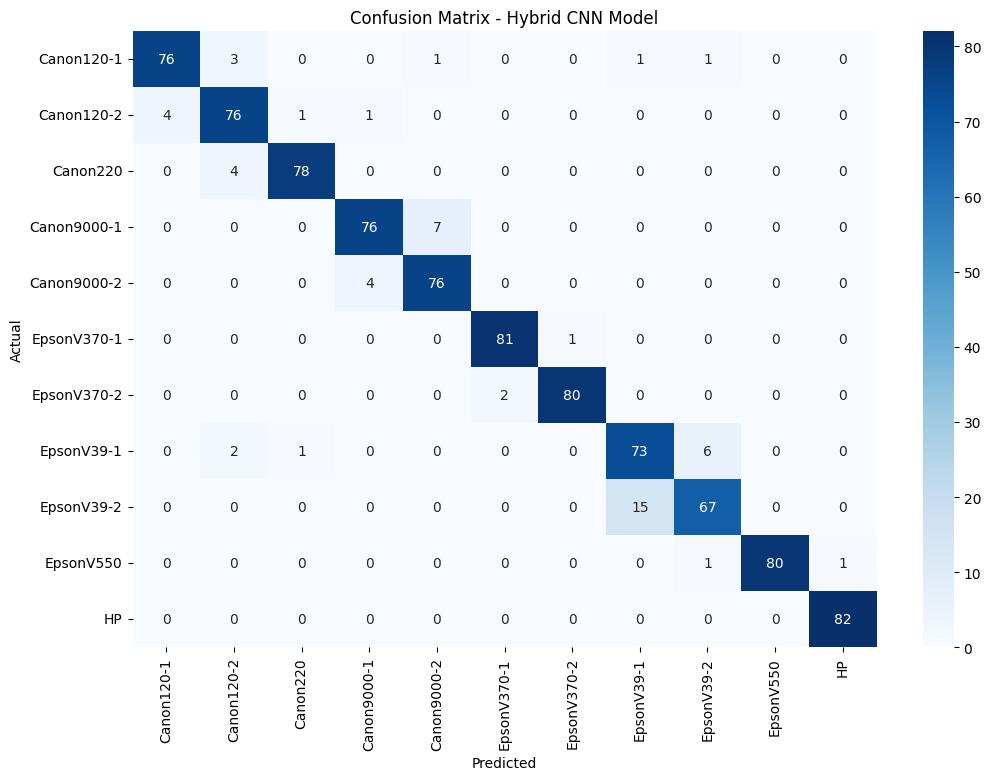


📄 Classification Report:
              precision    recall  f1-score   support

  Canon120-1       0.95      0.93      0.94        82
  Canon120-2       0.89      0.93      0.91        82
    Canon220       0.97      0.95      0.96        82
 Canon9000-1       0.94      0.92      0.93        83
 Canon9000-2       0.90      0.95      0.93        80
 EpsonV370-1       0.98      0.99      0.98        82
 EpsonV370-2       0.99      0.98      0.98        82
  EpsonV39-1       0.82      0.89      0.85        82
  EpsonV39-2       0.89      0.82      0.85        82
   EpsonV550       1.00      0.98      0.99        82
          HP       0.99      1.00      0.99        82

    accuracy                           0.94       901
   macro avg       0.94      0.94      0.94       901
weighted avg       0.94      0.94      0.94       901



In [56]:
# --------------------------
# CONFUSION MATRIX
# --------------------------
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

# Collect predictions from validation dataset
for (img_batch, feat_batch), label_batch in val_ds:
    preds = model.predict([img_batch, feat_batch], verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(label_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Hybrid CNN Model")
plt.show()

# Classification Report
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))